# 1. Imports

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.base import clone
import pandas as pd
import numpy as np
import random

from jmetal.operator.mutation import PolynomialMutation
from jmetal.operator.crossover import SBXCrossover
from jmetal.algorithm.singleobjective import GeneticAlgorithm
from jmetal.operator.selection import BinaryTournamentSelection
from jmetal.core.solution import FloatSolution
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.core.problem import Problem



# 2. Decision Algos

In [4]:
# # Chargement datasets

# df_yeast = pd.read_csv("yeast.csv")
# print(df_yeast)
# X_yeast = df_yeast.drop("Output", axis=1).to_numpy()
# y_yeast = df_yeast["Output"].to_numpy()
# #run_xp_on_dataset('yeast1',X,y)

df_diabetes = pd.read_csv("diabetes.csv")
print(df_diabetes.columns)
X = df_diabetes.drop("Outcome", axis=1).to_numpy()
y = df_diabetes["Outcome"].to_numpy()
#run_xp_on_dataset('Pima',X,y)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [5]:
skf = StratifiedKFold(n_splits=3)
fold = 0
for train, test in skf.split(X, y):
    fold += 1
    for seed in range(3):
        X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

accuracy_rf = round(accuracy_score(y_test, y_pred_rf),3)
f1_rf = round(f1_score(y_test, y_pred_rf,average='binary'),3)
precision_rf = round(precision_score(y_test, y_pred_rf),3)
recall_rf = round(recall_score(y_test, y_pred_rf),3)

In [7]:
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

accuracy_svc = round(accuracy_score(y_test, y_pred_svc),3)
f1_svc = round(f1_score(y_test, y_pred_svc,average='binary'),3)
precision_svc = round(precision_score(y_test, y_pred_svc),3)
recall_svc = round(recall_score(y_test, y_pred_svc),3)

In [8]:
c45 = DecisionTreeClassifier(max_depth=4, random_state=42)
c45.fit(X_train, y_train)
y_pred_c45 = c45.predict(X_test)

accuracy_c45 = round(accuracy_score(y_test, y_pred_c45),3)
f1_c45 = round(f1_score(y_test, y_pred_c45,average='binary'),3)
precision_c45 = round(precision_score(y_test, y_pred_c45),3)
recall_c45 = round(recall_score(y_test, y_pred_c45),3)

In [9]:
print(f1_rf, f1_svc, f1_c45)

0.632 0.595 0.519


# 3. Implementation of Partial Classification

In [10]:
class PartialClassificationProblem(Problem):
    """
    Problème de classification partielle mono-objectif.
    Une solution = une règle avec bornes [bi, bs] pour chaque attribut.
    Objectif = maximiser F1 (donc minimiser -F1).
    """

    def __init__(self, X, y):
        # Appeler le constructeur parent en premier
        super().__init__()
        
        self.X = X
        self.y = y
        self.n_attributes = X.shape[1]

        # Définition des bornes globales des attributs
        mins = X.min(axis=0)
        maxs = X.max(axis=0)

        self.lower_bound = []
        self.upper_bound = []

        for i in range(self.n_attributes):
            self.lower_bound.extend([mins[i], mins[i]])
            self.upper_bound.extend([maxs[i], maxs[i]])

    def number_of_variables(self) -> int:
        return 2 * self.n_attributes

    def number_of_objectives(self) -> int:
        return 1

    def number_of_constraints(self) -> int:
        return 0

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        variables = solution.variables
        y_pred = []

        for instance in self.X:
            rule_active = True

            for i in range(self.n_attributes):
                bi = variables[2 * i]
                bs = variables[2 * i + 1]

                # Attribut actif si bi <= bs
                if bi <= bs:
                    if not (bi <= instance[i] <= bs):
                        rule_active = False
                        break

            y_pred.append(1 if rule_active else 0)

        # Gestion cas sans prédictions positives
        if sum(y_pred) == 0:
            f1 = 0.0
        else:
            f1 = f1_score(self.y, y_pred, average='binary', zero_division=0)

        solution.objectives[0] = -f1
        return solution

    def create_solution(self) -> FloatSolution:
        solution = FloatSolution(
            self.lower_bound,
            self.upper_bound,
            self.number_of_objectives(),
            self.number_of_constraints()
        )

        solution.variables = [
            random.uniform(self.lower_bound[i], self.upper_bound[i])
            for i in range(self.number_of_variables())
        ]

        return solution

    def name(self):
        return "PartialClassificationProblem"

In [11]:
#### Random Entries from Diabetes Dataset
diabetes_1 = df_diabetes[df_diabetes["Outcome"] == 1].sample(3)
diabetes_0 = df_diabetes[df_diabetes["Outcome"] == 0].sample(3)

In [12]:
# Création du problème avec vos données
problem = PartialClassificationProblem(X_train, y_train)

# Test de création et évaluation
solution = problem.create_solution()
evaluated_solution = problem.evaluate(solution)
print("F1 (négatif car minimisation) :", evaluated_solution.objectives[0])

# Configuration et lancement de l'algorithme génétique
algorithm = GeneticAlgorithm(
    problem=problem,
    population_size=100,
    offspring_population_size=100,
    mutation=PolynomialMutation(probability=1.0 / problem.number_of_variables()),
    crossover=SBXCrossover(probability=0.9),
    selection=BinaryTournamentSelection(),
    termination_criterion=StoppingByEvaluations(max_evaluations=25000)
)

algorithm.run()
result = algorithm.solutions[0]
# Affichage des résultats
print(f"\nMeilleure solution trouvée:")
print(f"F1 = {-result.objectives[0]:.3f}")

# Calcul des métriques détaillées
variables = result.variables
y_pred = []
for instance in X_train:
    rule_active = True
    for i in range(problem.n_attributes):
        bi = variables[2 * i]
        bs = variables[2 * i + 1]
        if bi <= bs:
            if not (bi <= instance[i] <= bs):
                rule_active = False
                break
    y_pred.append(1 if rule_active else 0)

precision = precision_score(y_train, y_pred, average='binary', zero_division=0)
recall = recall_score(y_train, y_pred, average='binary', zero_division=0)
f1 = f1_score(y_train, y_pred, average='binary', zero_division=0)

print(f"Precision = {precision:.3f}")
print(f"Recall = {recall:.3f}")
print(f"F1 = {f1:.3f}")

# Décodage de la règle
print("\nRègle décodée:")
for i in range(problem.n_attributes):
    bi = variables[2 * i]
    bs = variables[2 * i + 1]
    if bi <= bs:
        print(f"  Attribut {i}: [{bi:.2f}, {bs:.2f}]")
    else:
        print(f"  Attribut {i}: désactivé")

[2026-03-03 04:17:33,144] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...


F1 (négatif car minimisation) : -0.011049723756906077


[2026-03-03 04:17:33,145] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 04:17:33,186] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 04:17:33,187] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 04:17:59,597] [jmetal.core.algorithm] [DEBUG] Finished!



Meilleure solution trouvée:
F1 = 0.676
Precision = 0.589
Recall = 0.793
F1 = 0.676

Règle décodée:
  Attribut 0: désactivé
  Attribut 1: [99.84, 196.66]
  Attribut 2: désactivé
  Attribut 3: désactivé
  Attribut 4: désactivé
  Attribut 5: [26.40, 60.84]
  Attribut 6: désactivé
  Attribut 7: [24.06, 62.11]


# Evaluation et Analyse des Résultats

## évaluation règle sur X_Test

In [13]:
def predict_with_rule(variables, X):
    """Retourne y_pred (0/1) pour une règle encodée par variables."""
    n_attributes = X.shape[1]
    y_pred = []

    for instance in X:
        rule_active = True
        for i in range(n_attributes):
            bi = variables[2*i]
            bs = variables[2*i + 1]
            if bi <= bs:  # attribut activé
                if not (bi <= instance[i] <= bs):
                    rule_active = False
                    break
        y_pred.append(1 if rule_active else 0)

    return np.array(y_pred)

def metrics_binary(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return precision, recall, f1

In [14]:
if 'algorithm' in globals():
    best = algorithm.solutions[0]
elif 'result' in globals():
    best = result
else:
    raise NameError("Neither 'algorithm' nor 'result' is defined. Run the algorithm cell first.")

y_pred_test = predict_with_rule(best.variables, X_test)

p, r, f1 = metrics_binary(y_test, y_pred_test)
print(f"TEST precision={p:.3f}, recall={r:.3f}, f1={f1:.3f}")

TEST precision=0.540, recall=0.685, f1=0.604


## run et stockage

In [15]:
def run_ga_once(X_train, y_train, seed=0, max_evals=25000,
                pop=100, off=100, cx=0.9, mut=None):

    random.seed(seed)
    np.random.seed(seed)

    problem = PartialClassificationProblem(X_train, y_train)
    if mut is None:
        mut = 1.0 / problem.number_of_variables()

    algorithm = GeneticAlgorithm(
        problem=problem,
        population_size=pop,
        offspring_population_size=off,
        mutation=PolynomialMutation(probability=mut),
        crossover=SBXCrossover(probability=cx),
        selection=BinaryTournamentSelection(),
        termination_criterion=StoppingByEvaluations(max_evaluations=max_evals)
    )
    algorithm.run()
    return algorithm.solutions[0] 

## résultat

In [16]:
runs = 20
results = []

for run in range(runs):
    best = run_ga_once(X_train, y_train, seed=run)
    y_pred_test = predict_with_rule(best.variables, X_test)
    p, r, f1 = metrics_binary(y_test, y_pred_test)
    results.append((p, r, f1))

results = np.array(results)
print("Moyenne TEST (P,R,F1) =", results.mean(axis=0))
print("Std TEST (P,R,F1)     =", results.std(axis=0))

[2026-03-03 04:17:59,632] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 04:17:59,633] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 04:17:59,694] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 04:17:59,694] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 04:18:26,080] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 04:18:26,083] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 04:18:26,083] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 04:18:26,132] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 04:18:26,132] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 04:18:52,934] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 04:18:52,937] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 04:18:52,938] [jm

Moyenne TEST (P,R,F1) = [0.52180558 0.70449438 0.59723066]
Std TEST (P,R,F1)     = [0.030961   0.04807886 0.00702206]


## score

In [17]:
seeds = [42, 1337, 65535]
skf = StratifiedKFold(n_splits=3)

all_scores = []  # (fold, seed, precision, recall, f1)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    for s in seeds:
        best = run_ga_once(X_train, y_train, seed=s)
        y_pred_test = predict_with_rule(best.variables, X_test)
        p, r, f1 = metrics_binary(y_test, y_pred_test)
        all_scores.append((fold, s, p, r, f1))

df_ga = pd.DataFrame(all_scores, columns=["fold","seed","precision","recall","f1"])
print(df_ga)
print(df_ga[["precision","recall","f1"]].mean())

[2026-03-03 04:26:44,687] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 04:26:44,688] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 04:26:44,756] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 04:26:44,756] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 04:27:10,575] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 04:27:10,578] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 04:27:10,579] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 04:27:10,633] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 04:27:10,633] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 04:27:35,719] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 04:27:35,722] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 04:27:35,723] [jm

   fold   seed  precision    recall        f1
0     1     42   0.545455  0.666667  0.600000
1     1   1337   0.578431  0.655556  0.614583
2     1  65535   0.545455  0.666667  0.600000
3     2     42   0.475248  0.539326  0.505263
4     2   1337   0.592233  0.685393  0.635417
5     2  65535   0.475728  0.550562  0.510417
6     3     42   0.545455  0.674157  0.603015
7     3   1337   0.539823  0.685393  0.603960
8     3  65535   0.535088  0.685393  0.600985
precision    0.536990
recall       0.645457
f1           0.585960
dtype: float64


# 5 - Analyse des résultats

In [18]:
budgets = [1000, 2000, 5000, 10000, 15000, 25000]

## évaluation

In [39]:
budget_rows = []

# If eval_ga_cv is not defined elsewhere, define a helper here
if 'eval_ga_cv' not in globals():
    def eval_ga_cv(X, y, n_splits=3, seeds=(0,), pop=100, off=100, cx_prob=0.9, mut_prob=None, max_evals=25000):
        rows = []
        skf_local = StratifiedKFold(n_splits=n_splits)
        for fold, (train_idx, test_idx) in enumerate(skf_local.split(X, y), start=1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            for s in seeds:
                best = run_ga_once(X_train, y_train, seed=s, max_evals=max_evals, pop=pop, off=off, cx=cx_prob, mut=mut_prob)
                y_pred_test = predict_with_rule(best.variables, X_test)
                p, r, f1 = metrics_binary(y_test, y_pred_test)
                rows.append({'fold': fold, 'seed': s, 'precision': p, 'recall': r, 'f1': f1})
        return pd.DataFrame(rows)

for b in budgets:
    df_b = eval_ga_cv(
        X, y,
        n_splits=3,
        seeds=(0,1,2),   # 3 runs par fold
        pop=100,
        off=100,
        cx_prob=0.9,
        mut_prob=None,
        max_evals=b
    )

    budget_rows.append({
        "max_evals": b,
        "f1_mean": df_b["f1"].mean(),
        "f1_std": df_b["f1"].std(),
        "precision_mean": df_b["precision"].mean(),
        "recall_mean": df_b["recall"].mean()
    })

df_budget = pd.DataFrame(budget_rows)
df_budget

[2026-03-03 05:52:04,800] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:52:04,803] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:52:04,855] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:52:04,855] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:52:05,692] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:52:05,695] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:52:05,696] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:52:05,736] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:52:05,737] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:52:06,522] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:52:06,526] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:52:06,526] [jm

,max_evals,f1_mean,f1_std,precision_mean,recall_mean
0,1000,0.588961,0.019683,0.499458,0.741448
1,2000,0.590949,0.013425,0.507909,0.721487
2,5000,0.576215,0.042545,0.531985,0.645402
3,10000,0.576538,0.042764,0.530050,0.649119
4,15000,0.581691,0.045098,0.544246,0.636635
5,25000,0.582383,0.041821,0.537590,0.645374


## courbes

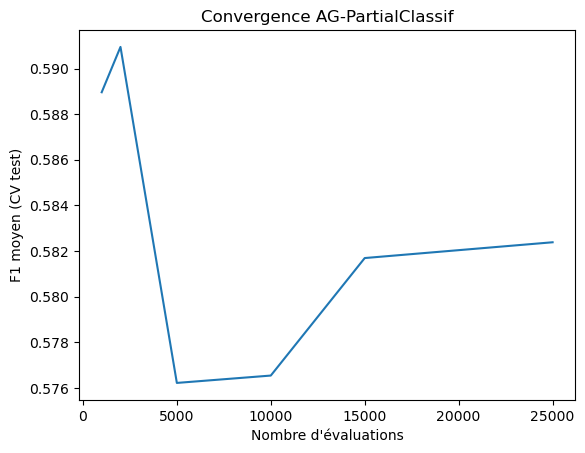

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_budget["max_evals"], df_budget["f1_mean"])
plt.xlabel("Nombre d'évaluations")
plt.ylabel("F1 moyen (CV test)")
plt.title("Convergence AG-PartialClassif")
plt.show()

## définition grid

In [23]:
param_grid = [
    {"pop": 50,  "cx_prob": 0.8, "mut_prob": None},
    {"pop": 50,  "cx_prob": 0.9, "mut_prob": None},
    {"pop": 100, "cx_prob": 0.8, "mut_prob": None},
    {"pop": 100, "cx_prob": 0.9, "mut_prob": None},

    {"pop": 50,  "cx_prob": 0.8, "mut_prob": 0.05},
    {"pop": 50,  "cx_prob": 0.9, "mut_prob": 0.05},
    {"pop": 100, "cx_prob": 0.8, "mut_prob": 0.05},
    {"pop": 100, "cx_prob": 0.9, "mut_prob": 0.05},

    {"pop": 50,  "cx_prob": 0.8, "mut_prob": 0.2},
    {"pop": 50,  "cx_prob": 0.9, "mut_prob": 0.2},
    {"pop": 100, "cx_prob": 0.8, "mut_prob": 0.2},
    {"pop": 100, "cx_prob": 0.9, "mut_prob": 0.2},
]

In [25]:
# Example: call eval_ga_cv with dataset variables (replace params as needed)
df_example = eval_ga_cv(X, y, n_splits=3, seeds=(0,1,2), pop=50, off=50, cx_prob=0.9, mut_prob=None, max_evals=1000)
print(df_example.head())

[2026-03-03 05:13:39,249] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:13:39,250] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:13:39,275] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:13:39,275] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:13:40,235] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:13:40,238] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:13:40,239] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:13:40,260] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:13:40,261] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:13:41,141] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:13:41,143] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:13:41,144] [jm

   fold  seed  precision    recall        f1
0     1     0   0.511278  0.755556  0.609865
1     1     1   0.445652  0.911111  0.598540
2     1     2   0.417910  0.933333  0.577320
3     2     0   0.445455  0.550562  0.492462
4     2     1   0.423913  0.876404  0.571429


In [27]:
all_results = []
max_evals_choice = 10000

for i, params in enumerate(param_grid, start=1):
    print(f"Testing config {i} : {params}")

    df = eval_ga_cv(
        X, y,
        n_splits=3,
        seeds=(0,1,2),
        pop=params["pop"],
        off=params["pop"],
        cx_prob=params["cx_prob"],
        mut_prob=params["mut_prob"],
        max_evals=max_evals_choice
    )

    df["config_id"] = i
    df["pop"] = params["pop"]
    df["cx_prob"] = params["cx_prob"]
    df["mut_prob"] = params["mut_prob"]

    all_results.append(df)

df_params = pd.concat(all_results, ignore_index=True)

[2026-03-03 05:14:34,356] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:14:34,358] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:14:34,393] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:14:34,394] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met


Testing config 1 : {'pop': 50, 'cx_prob': 0.8, 'mut_prob': None}


[2026-03-03 05:14:44,982] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:14:44,985] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:14:44,985] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:14:45,010] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:14:45,011] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:14:54,993] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:14:54,996] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:14:54,996] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:14:55,022] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:14:55,023] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:15:05,227] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:15:05,230] [jmetal.core.algorithm] [DEBUG

Testing config 2 : {'pop': 50, 'cx_prob': 0.9, 'mut_prob': None}


[2026-03-03 05:16:18,000] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:16:18,004] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:16:18,004] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:16:18,026] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:16:18,027] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:16:28,180] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:16:28,183] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:16:28,184] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:16:28,207] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:16:28,207] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:16:38,426] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:16:38,429] [jmetal.core.algorithm] [DEBUG

...

[2026-03-03 05:28:34,115] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:28:34,117] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:28:34,118] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:28:34,139] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:28:34,139] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:28:43,651] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:28:43,654] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:28:43,654] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:28:43,678] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:28:43,678] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:28:52,929] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:28:52,931] [jmetal.core.algorithm] [DEBUG

Testing config 11 : {'pop': 100, 'cx_prob': 0.8, 'mut_prob': 0.2}


[2026-03-03 05:30:00,474] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:30:00,477] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:30:00,477] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:30:00,517] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:30:00,518] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:30:09,724] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:30:09,727] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:30:09,728] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:30:09,776] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:30:09,776] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:30:19,240] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:30:19,243] [jmetal.core.algorithm] [DEBUG

Testing config 12 : {'pop': 100, 'cx_prob': 0.9, 'mut_prob': 0.2}


[2026-03-03 05:31:25,523] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:31:25,526] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:31:25,526] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:31:25,566] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:31:25,566] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:31:35,163] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:31:35,166] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-03 05:31:35,166] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-03 05:31:35,217] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-03 05:31:35,217] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-03 05:31:44,635] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-03 05:31:44,639] [jmetal.core.algorithm] [DEBUG

In [28]:
summary = (
    df_params
    .groupby(["config_id","pop","cx_prob","mut_prob"], as_index=False)
    .agg(
        F1_mean=("f1","mean"),
        F1_std=("f1","std"),
        Precision_mean=("precision","mean"),
        Recall_mean=("recall","mean")
    )
)

summary = summary.sort_values("F1_mean", ascending=False)
summary

,config_id,pop,cx_prob,mut_prob,F1_mean,F1_std,Precision_mean,Recall_mean
3,8,100,0.9,0.05,0.611323,0.017239,0.548454,0.701637
7,12,100,0.9,0.20,0.607247,0.015451,0.542192,0.692787
4,9,50,0.8,0.20,0.597622,0.029425,0.530940,0.692815
6,11,100,0.8,0.20,0.594744,0.035308,0.541795,0.669039
1,6,50,0.9,0.05,0.592680,0.035862,0.536661,0.676668
2,7,100,0.8,0.05,0.589081,0.048316,0.542457,0.648967
5,10,50,0.9,0.20,0.580708,0.050621,0.536586,0.636746
0,5,50,0.8,0.05,0.567509,0.048111,0.496385,0.682466


## boxplot

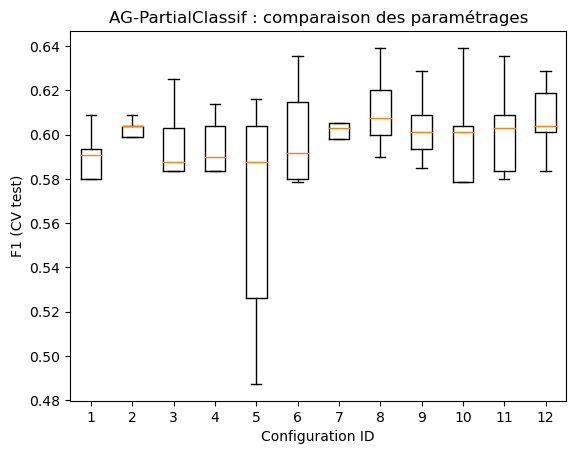

In [29]:
import matplotlib.pyplot as plt

data = [
    df_params[df_params["config_id"]==cid]["f1"].values
    for cid in sorted(df_params["config_id"].unique())
]

plt.figure()
plt.boxplot(data, showfliers=False)
plt.xlabel("Configuration ID")
plt.ylabel("F1 (CV test)")
plt.title("AG-PartialClassif : comparaison des paramétrages")
plt.show()

## identification meilleur paramétrage

In [30]:
best_config = summary.iloc[0]
best_config

config_id           8.000000
pop               100.000000
cx_prob             0.900000
mut_prob            0.050000
F1_mean             0.611323
F1_std              0.017239
Precision_mean      0.548454
Recall_mean         0.701637
Name: 3, dtype: float64

## évaluation classique

In [31]:
def eval_model_cv(model, X, y, n_splits=3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    rows = []

    for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X[tr], X[te]
        y_train, y_test = y[tr], y[te]

        m = clone(model)
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)

        p = precision_score(y_test, y_pred, zero_division=0)
        r = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        rows.append({"precision": p, "recall": r, "f1": f1})

    return pd.DataFrame(rows)

## RM/SVM/c4.5

In [35]:
from sklearn.base import clone
df_rf = eval_model_cv(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y
)

df_svm = eval_model_cv(
    make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=42)),
    X, y
)

df_c45 = eval_model_cv(
    DecisionTreeClassifier(max_depth=4, random_state=42),
    X, y
)

In [36]:
best_params = {
    "pop": 100,
    "off": 100,
    "cx_prob": 0.9,
    "mut_prob": None,
    "max_evals": 10000
}

In [37]:
best_params = {
    "pop": 100,
    "off": 100,
    "cx_prob": 0.9,
    "mut_prob": None,
    "max_evals": 10000
}

## tableau comparatif

In [38]:
def mean_metrics(df):
    return pd.Series({
        "F1-mesure": df["f1"].mean(),
        "Precision": df["precision"].mean(),
        "Recall": df["recall"].mean()
    })

final_table = pd.DataFrame({
    "RF": mean_metrics(df_rf),
    "SVM": mean_metrics(df_svm),
    "C4.5": mean_metrics(df_c45),
    "AG-PartialClassif": mean_metrics(df_ga)
})

final_table

,RF,SVM,C4.5,AG-PartialClassif
F1-mesure,0.621429,0.615094,0.616932,0.585960
Precision,0.664729,0.671717,0.635240,0.536990
Recall,0.585893,0.570953,0.626758,0.645457


## boxplot

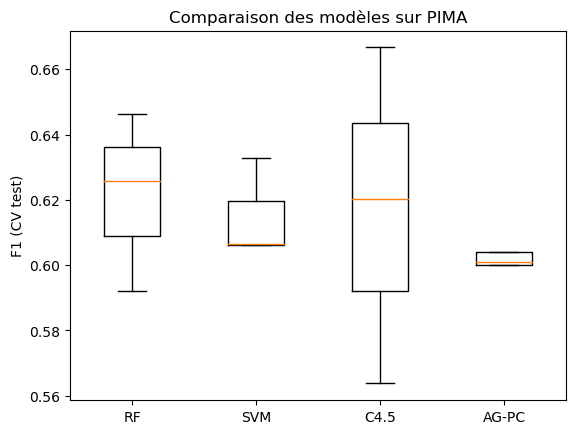

In [40]:
plt.figure()
plt.boxplot([
    df_rf["f1"],
    df_svm["f1"],
    df_c45["f1"],
    df_ga["f1"]
], labels=["RF","SVM","C4.5","AG-PC"], showfliers=False)

plt.ylabel("F1 (CV test)")
plt.title("Comparaison des modèles sur PIMA")
plt.show()